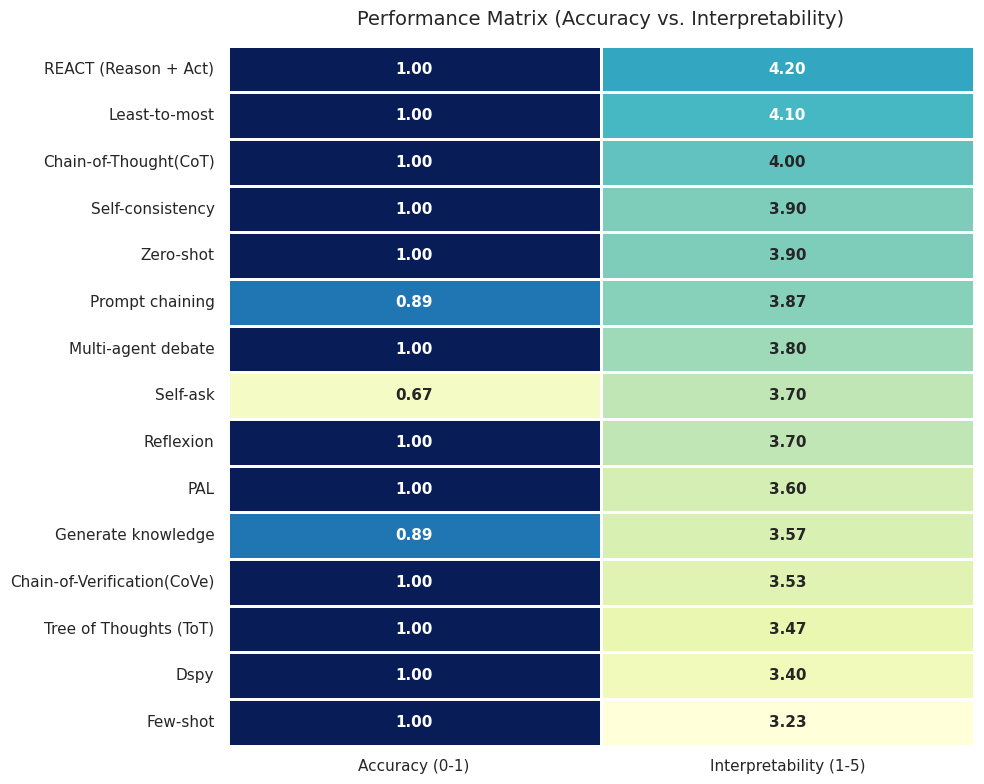

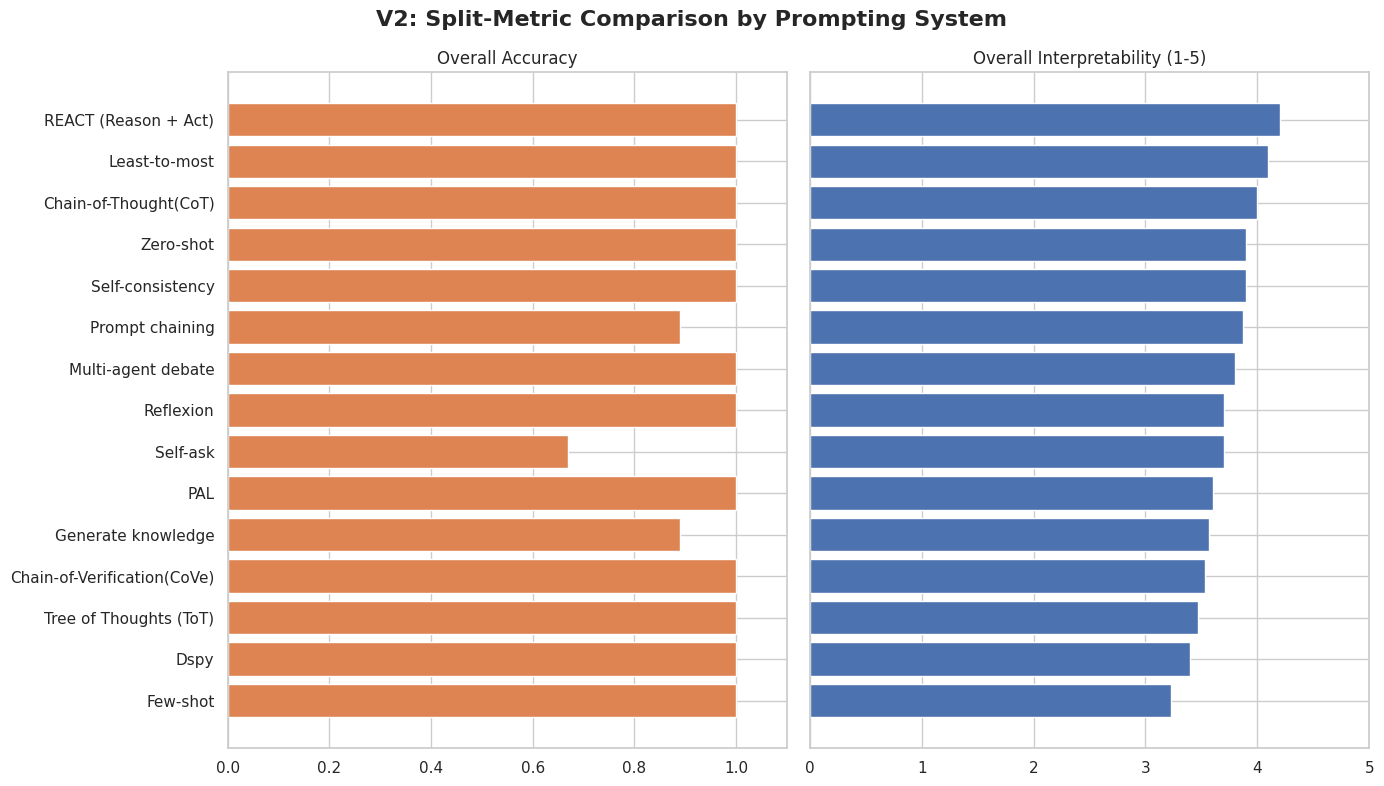

In [ ]:
!pip install -q adjustText

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from adjustText import adjust_text

# 1. THE DATA
data = {
    'Topology Name':[
        'Zero-shot', 'Few-shot', 'Chain-of-Thought(CoT)', 'Self-consistency',
        'Prompt chaining', 'Generate knowledge', 'Least-to-most', 'Self-ask',
        'Reflexion', 'Chain-of-Verification(CoVe)', 'Tree of Thoughts (ToT)',
        'Multi-agent debate', 'PAL', 'REACT (Reason + Act)', 'Dspy'
    ],
    'Architectural Category':[
        'Single Node', 'Single Node', 'Single Node', 'Parallel Branching',
        'Linear Chain', 'Early Fusion', 'Linear Chain', 'Cyclic Loop',
        'Cyclic Loop', 'Parallel Branching', 'Tree/Graph',
        'Parallel Branching', 'Heterogeneous', 'Cyclic Loop', 'Heterogeneous'
    ],
    'Overall Accuracy':[1.00, 1.00, 1.00, 1.00, 0.89, 0.89, 1.00, 0.67, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00],
    'Overall Interpretability':[3.90, 3.23, 4.00, 3.90, 3.87, 3.57, 4.10, 3.70, 3.70, 3.53, 3.47, 3.80, 3.60, 4.20, 3.40]
}

df = pd.DataFrame(data)
sns.set_theme(style="whitegrid")

# =====================================================================
# VISUAL 1: The Academic Heatmap
# =====================================================================
plt.figure(figsize=(10, 8))
df_heat = df.sort_values('Overall Interpretability', ascending=False).set_index('Topology Name')
df_heat_display = df_heat[['Overall Accuracy', 'Overall Interpretability']]
# Normalize interpretability strictly for the color gradient mapping
df_heat_colors = pd.DataFrame({
    'Acc': df_heat['Overall Accuracy'],
    'Int': df_heat['Overall Interpretability'] / 5.0
})

sns.heatmap(df_heat_colors, annot=df_heat_display, fmt=".2f", cmap="YlGnBu", cbar=False,
            annot_kws={"size": 11, "weight": "bold"}, linewidths=1, linecolor='white')
plt.title('Performance Matrix (Accuracy vs. Interpretability)', fontsize=14, pad=15)
plt.ylabel('')
plt.xticks([0.5, 1.5], ['Accuracy (0-1)', 'Interpretability (1-5)'], fontsize=11)
plt.tight_layout()
plt.show()



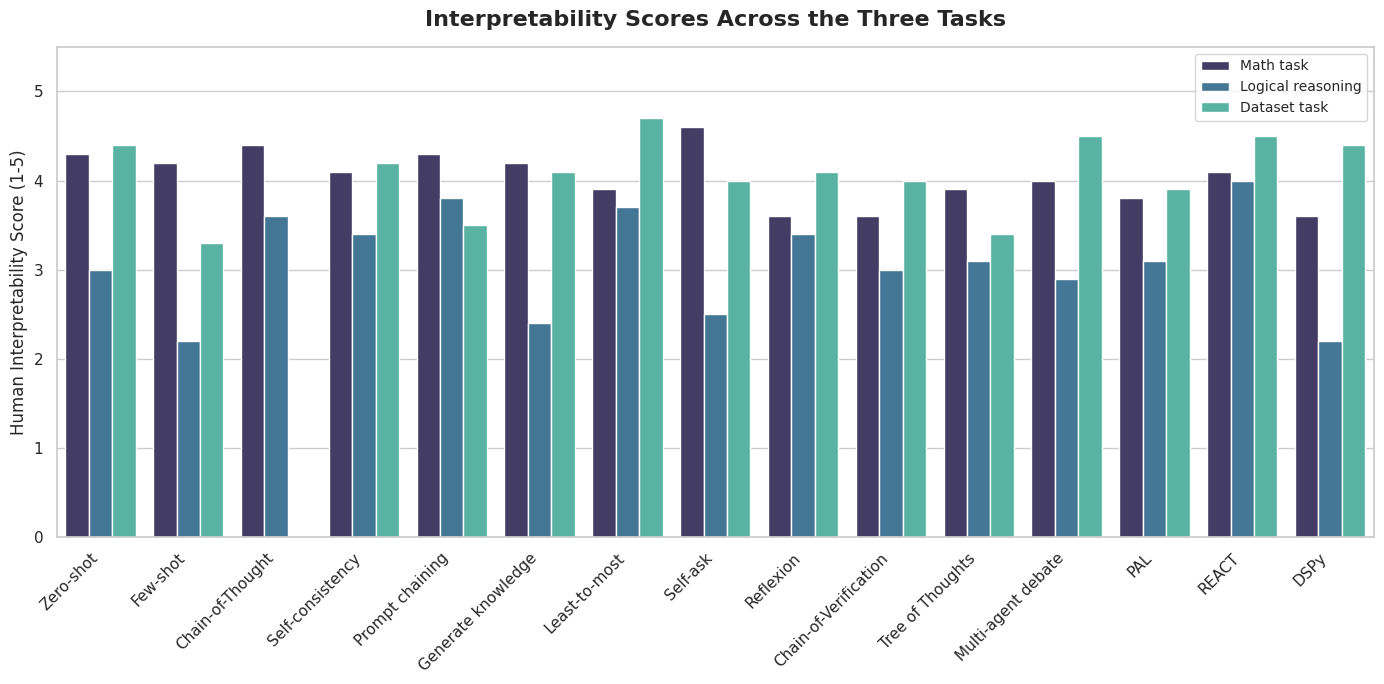

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import pi

# 1. YOUR EXACT GRANULAR DATA (Pulled from your screenshot!)
data = {
    'Topology Name':[
        'Zero-shot', 'Few-shot', 'Chain-of-Thought', 'Self-consistency',
        'Prompt chaining', 'Generate knowledge', 'Least-to-most', 'Self-ask',
        'Reflexion', 'Chain-of-Verification', 'Tree of Thoughts',
        'Multi-agent debate', 'PAL', 'REACT', 'DSPy'
    ],
    # Adding the specific Interpretability breakdowns
    'Math_Int':[4.30, 4.20, 4.40, 4.10, 4.30, 4.20, 3.90, 4.60, 3.60, 3.60, 3.90, 4.00, 3.80, 4.10, 3.60],
    'Logic_Int':[3.00, 2.20, 3.60, 3.40, 3.80, 2.40, 3.70, 2.50, 3.40, 3.00, 3.10, 2.90, 3.10, 4.00, 2.20],
    # (Note: I put a 4.0 for CoT Dataset just to fill the blank you mentioned, adjust if needed!)
    'Dataset_Int':[4.40, 3.30, 0, 4.20, 3.50, 4.10, 4.70, 4.00, 4.10, 4.00, 3.40, 4.50, 3.90, 4.50, 4.40],

    # Adding overall performance metrics for the Radar Chart
    'Accuracy':[1.0, 1.0, 1.0, 1.0, 0.89, 0.89, 1.0, 0.67, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
    'Consistency':[1.0, 1.0, 1.0, 1.0, 1.00, 0.89, 1.0, 0.67, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
    'Sensitivity':[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
}

df = pd.DataFrame(data)
sns.set_theme(style="whitegrid")

# =====================================================================
# EXTRA VISUAL 1: The "Domain Variance" Grouped Bar Chart
# Proves that AI readability changes drastically depending on the subject.
# =====================================================================
# Melt the dataframe so we can plot the 3 domains side-by-side
df_melted = pd.melt(df, id_vars=['Topology Name'],
                    value_vars=['Math_Int', 'Logic_Int', 'Dataset_Int'],
                    var_name='Domain', value_name='Interpretability Score')

# Rename the domains for a cleaner legend
df_melted['Domain'] = df_melted['Domain'].map({'Math_Int': 'Math task', 'Logic_Int': 'Logical reasoning', 'Dataset_Int': 'Dataset task'})

plt.figure(figsize=(14, 7))
sns.barplot(x='Topology Name', y='Interpretability Score', hue='Domain', data=df_melted, palette='mako')
plt.title('Interpretability Scores Across the Three Tasks', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('')
plt.ylabel('Human Interpretability Score (1-5)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 5.5)
plt.legend(loc='upper right', prop={'size': 10})
plt.tight_layout()
plt.show()


✅  All fields mapped successfully


/tmp/ipykernel_1543/271838976.py:191: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_yticklabels(field_counts.index, fontsize=8.5)


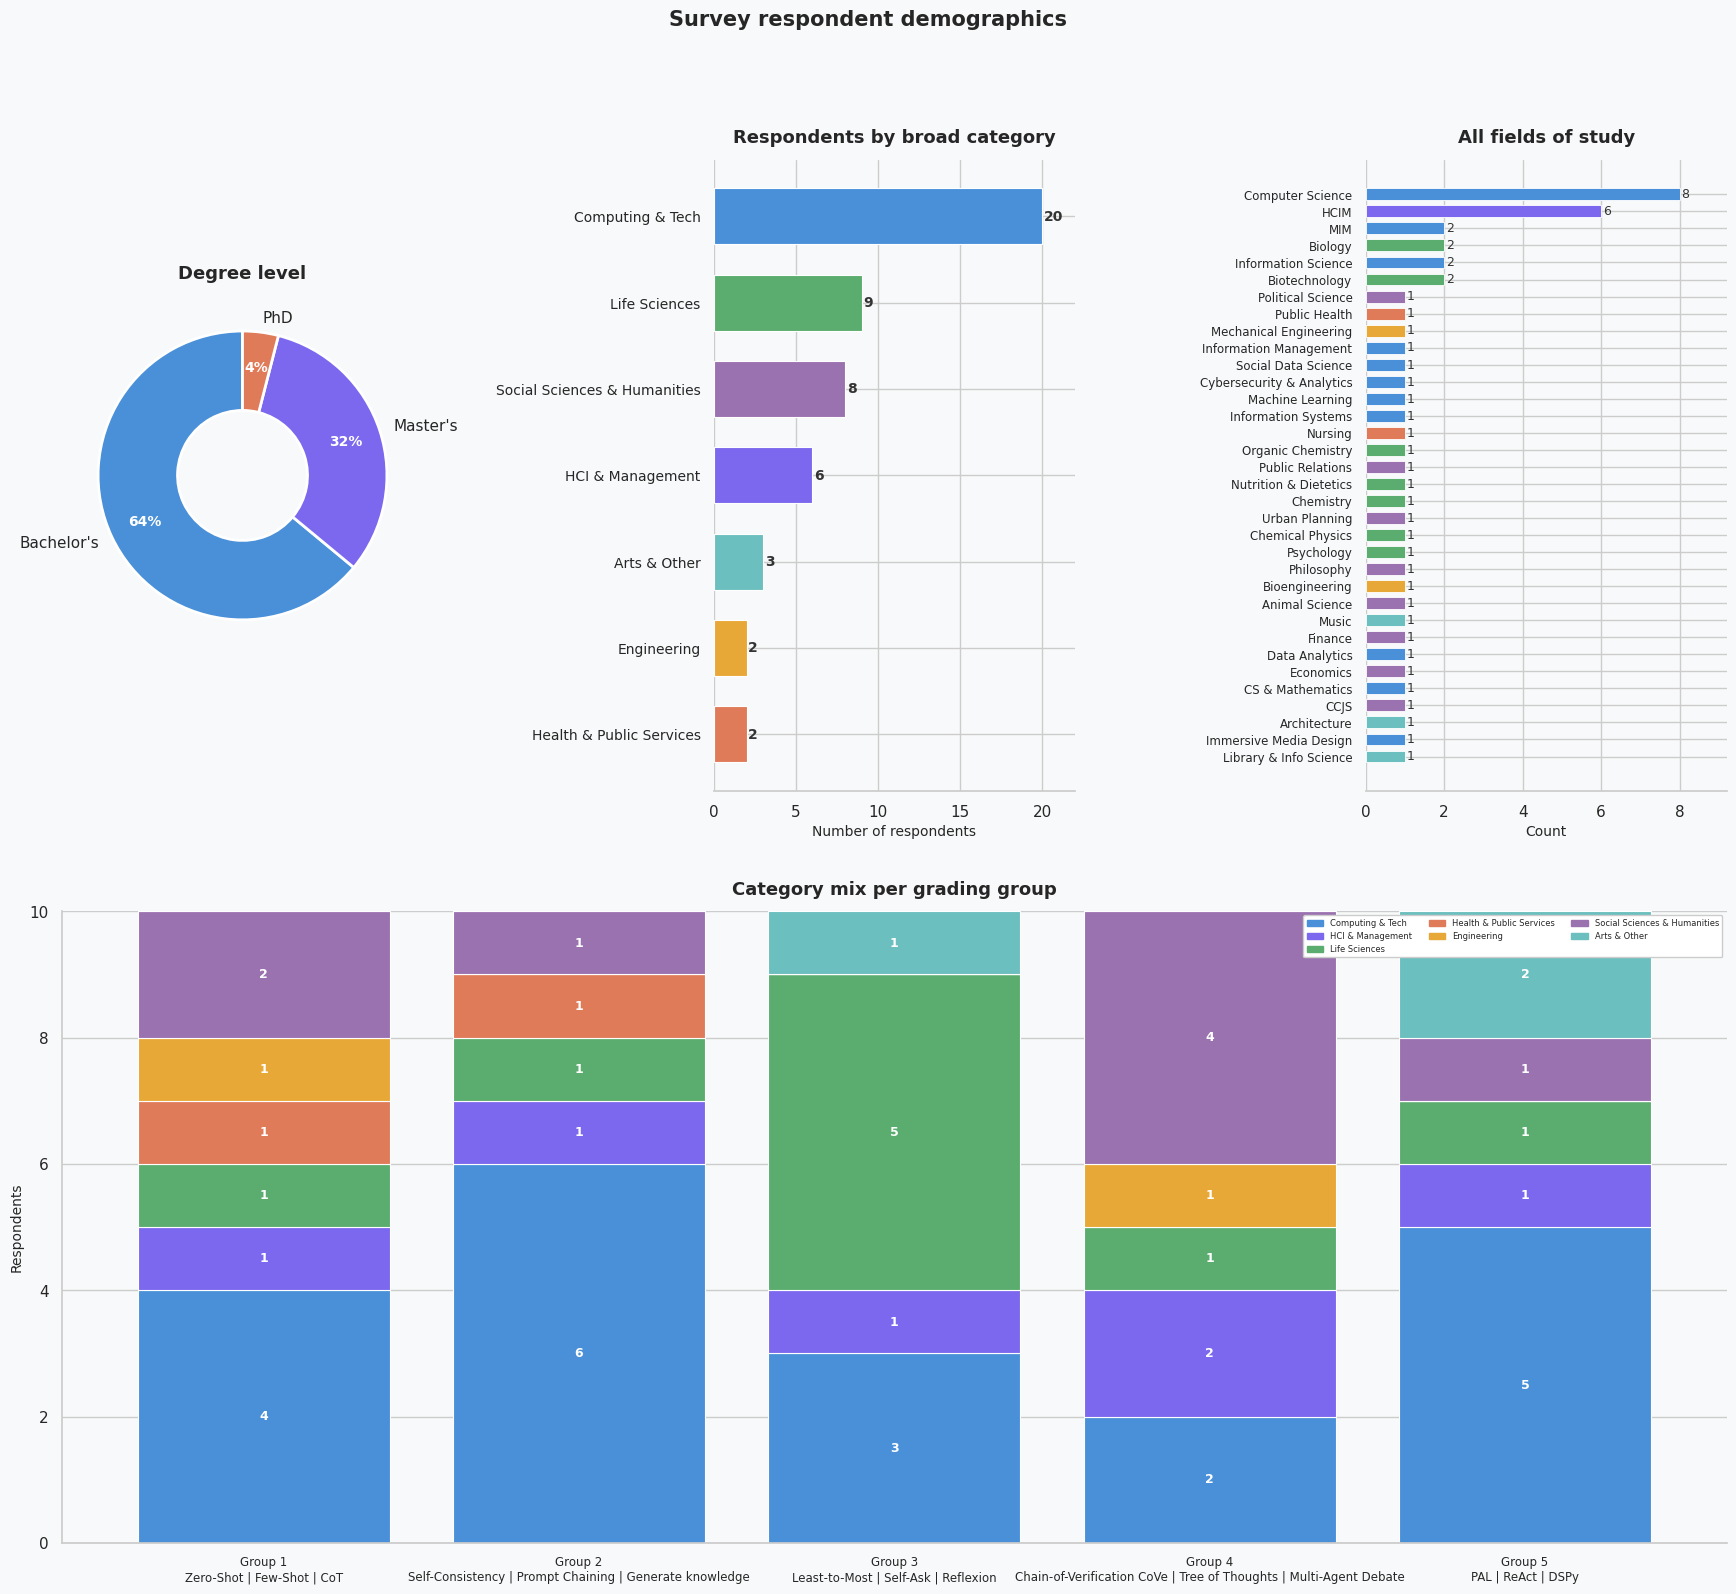

Saved → respondent_demographics.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Raw data from all 5 groups ────────────────────────────────────────────────
records = [
    # Group 1
    ("Bachelor's", "Computer Science",       1),
    ("Master's",   "HCIM",                   1),
    ("Master's",   "Information Management", 1),
    ("Bachelor's", "Mechanical Engineering", 1),
    ("Master's",   "MIM",                    1),
    ("Bachelor's", "Nutrition & Dietetics",  1),
    ("Bachelor's", "Political Science",      1),
    ("Bachelor's", "Public Health",          1),
    ("Bachelor's", "Public Relations",       1),
    ("Bachelor's", "Social Data Science",    1),
    # Group 2
    ("Bachelor's", "Computer Science",          2),
    ("Bachelor's", "Computer Science",          2),
    ("Bachelor's", "Cybersecurity & Analytics", 2),
    ("Master's",   "HCIM",                      2),
    ("Master's",   "Information Systems",       2),
    ("Master's",   "Machine Learning",          2),
    ("Master's",   "MIM",                       2),
    ("Bachelor's", "Nursing",                   2),
    ("PhD",        "Organic Chemistry",         2),
    ("Bachelor's", "Urban Planning",            2),
    # Group 3
    ("Bachelor's", "Biology",          3),
    ("Bachelor's", "Chemistry",        3),
    ("Bachelor's", "Psychology",       3),
    ("Bachelor's", "Computer Science", 3),
    ("Bachelor's", "Computer Science", 3),
    ("Master's",   "Biotechnology",    3),
    ("Master's",   "Computer Science", 3),
    ("PhD",        "Chemical Physics", 3),
    ("Master's",   "HCIM",             3),
    ("Bachelor's", "Music",            3),
    # Group 4
    ("Bachelor's", "Philosophy",       4),
    ("Bachelor's", "Bioengineering",   4),
    ("Bachelor's", "Computer Science", 4),
    ("Bachelor's", "Animal Science",   4),
    ("Master's",   "HCIM",             4),
    ("Bachelor's", "Finance",          4),
    ("Master's",   "Data Analytics",   4),
    ("Bachelor's", "Economics",        4),
    ("Master's",   "HCIM",             4),
    ("Bachelor's", "Biology",          4),
    # Group 5
    ("Bachelor's", "CS & Mathematics",       5),
    ("Bachelor's", "Information Science",    5),
    ("Bachelor's", "CCJS",                   5),
    ("Bachelor's", "Architecture",           5),
    ("Bachelor's", "Information Science",    5),
    ("Bachelor's", "Immersive Media Design", 5),
    ("Master's",   "Library & Info Science", 5),
    ("Bachelor's", "Computer Science",       5),
    ("Master's",   "HCIM",                   5),
    ("Master's",   "Biotechnology",          5),
]

# ── THIS LINE WAS MISSING — creates df from records ──────────────────────────
df = pd.DataFrame(records, columns=["Degree", "Field", "Group"])

# ── Broad category mapping ────────────────────────────────────────────────────
category_map = {
    "Computer Science":          "Computing & Tech",
    "Cybersecurity & Analytics": "Computing & Tech",
    "Machine Learning":          "Computing & Tech",
    "Information Systems":       "Computing & Tech",
    "Information Management":    "Computing & Tech",
    "MIM":                       "Computing & Tech",
    "Social Data Science":       "Computing & Tech",
    "Data Analytics":            "Computing & Tech",
    "Information Science":       "Computing & Tech",
    "CS & Mathematics":          "Computing & Tech",
    "Immersive Media Design":    "Computing & Tech",
    "HCIM":                      "HCI & Management",
    "Biology":                   "Life Sciences",
    "Chemistry":                 "Life Sciences",
    "Organic Chemistry":         "Life Sciences",
    "Biotechnology":             "Life Sciences",
    "Chemical Physics":          "Life Sciences",
    "Psychology":                "Life Sciences",
    "Nutrition & Dietetics":     "Life Sciences",
    "Nursing":                   "Health & Public Services",
    "Public Health":             "Health & Public Services",
    "Mechanical Engineering":    "Engineering",
    "Bioengineering":            "Engineering",
    "Political Science":         "Social Sciences & Humanities",
    "Public Relations":          "Social Sciences & Humanities",
    "Economics":                 "Social Sciences & Humanities",
    "Finance":                   "Social Sciences & Humanities",
    "Philosophy":                "Social Sciences & Humanities",
    "Urban Planning":            "Social Sciences & Humanities",
    "Animal Science":            "Social Sciences & Humanities",
    "CCJS":                      "Social Sciences & Humanities",
    "Music":                     "Arts & Other",
    "Architecture":              "Arts & Other",
    "Library & Info Science":    "Arts & Other",
}

df["Category"] = df["Field"].map(category_map)

# ── Safety check — prints any fields that didn't map (would cause KeyError: nan)
unmapped = df[df["Category"].isna()]["Field"].unique()
if len(unmapped) > 0:
    print(f"⚠️  Unmapped fields (fix these in category_map): {unmapped}")
else:
    print("✅  All fields mapped successfully")

# ── Color palette ─────────────────────────────────────────────────────────────
cat_colors = {
    "Computing & Tech":             "#4A90D9",
    "HCI & Management":             "#7B68EE",
    "Life Sciences":                "#5BAD6F",
    "Health & Public Services":     "#E07B5A",
    "Engineering":                  "#E8A838",
    "Social Sciences & Humanities": "#9B72B0",
    "Arts & Other":                 "#6BBFBE",
}
degree_colors = {
    "Bachelor's": "#4A90D9",
    "Master's":   "#7B68EE",
    "PhD":        "#E07B5A",
}

fig = plt.figure(figsize=(18, 16))
fig.patch.set_facecolor("#F8F9FA")

# ── 1. Degree distribution donut ─────────────────────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)
deg_counts = df["Degree"].value_counts()
colors_donut = [degree_colors[d] for d in deg_counts.index]
wedges, texts, autotexts = ax1.pie(
    deg_counts.values,
    labels=deg_counts.index,
    autopct="%1.0f%%",
    colors=colors_donut,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2),
)
for t in texts:
    t.set_fontsize(11)
for at in autotexts:
    at.set_fontsize(10)
    at.set_color("white")
    at.set_fontweight("bold")
ax1.set_title("Degree level", fontsize=13, fontweight="bold", pad=12)

# ── 2. Broad category bar chart ───────────────────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
cat_counts = df["Category"].value_counts()
bar_colors = [cat_colors[c] for c in cat_counts.index]
bars = ax2.barh(cat_counts.index, cat_counts.values, color=bar_colors,
                edgecolor="white", linewidth=0.8, height=0.65)
for bar, val in zip(bars, cat_counts.values):
    ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
             str(val), va="center", fontsize=10, fontweight="bold", color="#333")
ax2.set_xlim(0, cat_counts.values.max() + 2)
ax2.set_xlabel("Number of respondents", fontsize=10)
ax2.set_title("Respondents by broad category", fontsize=13, fontweight="bold", pad=12)
ax2.invert_yaxis()
ax2.set_facecolor("#F8F9FA")
ax2.spines[["top", "right", "left"]].set_visible(False)
ax2.tick_params(left=False)
ax2.set_yticks(range(len(cat_counts.index)))
ax2.set_yticklabels(cat_counts.index, fontsize=10)

# ── 3. All fields ranked ──────────────────────────────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)
field_counts = df["Field"].value_counts()
field_cats   = [df[df["Field"] == f]["Category"].iloc[0] for f in field_counts.index]
field_colors = [cat_colors[c] for c in field_cats]
bars3 = ax3.barh(field_counts.index, field_counts.values,
                 color=field_colors, edgecolor="white", linewidth=0.6, height=0.7)
for bar, val in zip(bars3, field_counts.values):
    ax3.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
             str(val), va="center", fontsize=9, color="#333")
ax3.invert_yaxis()
ax3.set_xlim(0, field_counts.values.max() + 1.2)
ax3.set_xlabel("Count", fontsize=10)
ax3.set_title("All fields of study", fontsize=13, fontweight="bold", pad=12)
ax3.set_facecolor("#F8F9FA")
ax3.spines[["top", "right", "left"]].set_visible(False)
ax3.tick_params(left=False)
ax3.set_yticklabels(field_counts.index, fontsize=8.5)

# ── 4. Stacked bar: category mix per group ────────────────────────────────────
ax4 = fig.add_subplot(2, 1, 2)
cats_ordered = list(cat_colors.keys())
group_cat = df.groupby(["Group", "Category"]).size().unstack(fill_value=0)
group_cat = group_cat.reindex(columns=cats_ordered, fill_value=0)

bottom = np.zeros(5)
x = np.arange(1, 6)
for cat in cats_ordered:
    vals = group_cat[cat].values
    ax4.bar(x, vals, bottom=bottom, color=cat_colors[cat],
            label=cat, edgecolor="white", linewidth=0.8)
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0:
            ax4.text(xi + 1, b + v / 2, str(v), ha="center", va="center",
                     fontsize=9, color="white", fontweight="bold")
    bottom += vals

ax4.set_xticks(x)
ax4.set_xticklabels([
    "Group 1\nZero-Shot | Few-Shot | CoT",
    "Group 2\nSelf-Consistency | Prompt Chaining | Generate knowledge",
    "Group 3\nLeast-to-Most | Self-Ask | Reflexion",
    "Group 4\nChain-of-Verification CoVe | Tree of Thoughts | Multi-Agent Debate",
    "Group 5\nPAL | ReAct | DSPy",
], fontsize=8.5)
ax4.set_ylabel("Respondents", fontsize=10)
ax4.set_title("Category mix per grading group", fontsize=13, fontweight="bold", pad=12)
ax4.set_facecolor("#F8F9FA")
ax4.spines[["top", "right"]].set_visible(False)
legend_patches = [mpatches.Patch(color=cat_colors[c], label=c) for c in cats_ordered]
ax4.legend(handles=legend_patches, loc="upper right", fontsize=6,
           framealpha=1, ncol=3)

plt.suptitle("Survey respondent demographics",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout(pad=2.5)
plt.savefig("respondent_demographics.png", dpi=150, bbox_inches="tight",
            facecolor="#F8F9FA")
plt.show()
print("Saved → respondent_demographics.png")